# 1. Configuração do Ambiente e Bibliotecas 🛠️

Nesta primeira etapa, preparamos o ambiente de execução.
* **Instalação Forçada:** Garantimos que bibliotecas críticas (`nltk`, `ipywidgets`) estejam instaladas no kernel atual para evitar erros de importação.
* **Caminhos:** Adicionamos a raiz do projeto ao sistema para que o notebook consiga acessar nossos módulos personalizados (`src.models`, etc).

In [2]:
import sys
!{sys.executable} -m pip install nltk
import sys
!{sys.executable} -m pip install ipywidgets
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import sys
import os
from xgboost import XGBClassifier

# Configuração visual
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

# Caminhos (ajuste se necessário)
sys.path.append(os.path.abspath('..'))
caminho_dados = '../data/processed/dataset_espelhos.csv'
caminho_modelo = '../models/xgboost_model.json'

print("✅ Ambiente de IA Configurado.")


[notice] A new release of pip is available: 25.1.1 -> 25.3
[notice] To update, run: C:\Users\gfasg\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip

[notice] A new release of pip is available: 25.1.1 -> 25.3
[notice] To update, run: C:\Users\gfasg\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


✅ Ambiente de IA Configurado.


# 2. Diagnóstico dos Dados: O Problema do Desequilíbrio 🚨

Carregamos os dados processados dos espelhos médicos e simulamos a decisão de regulação baseada no protocolo.

**O Desafio:**
Como podemos ver no gráfico abaixo, em um cenário real de regulação, a grande maioria dos pacientes é **Reprovada** (Barras Vermelhas) e pouquíssimos são **Aprovados** (Barras Verdes).

Isso cria um viés perigoso: se treinarmos a IA assim, ela aprenderá que o jeito mais fácil de acertar é **reprovar todo mundo**.

C:\Users\gfasg\AppData\Local\Temp\ipykernel_32592\1074967983.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=labels, y=contagem.values, palette=['#e74c3c', '#2ecc71'])
C:\Users\gfasg\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128680 (\N{POLICE CARS REVOLVING LIGHT}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


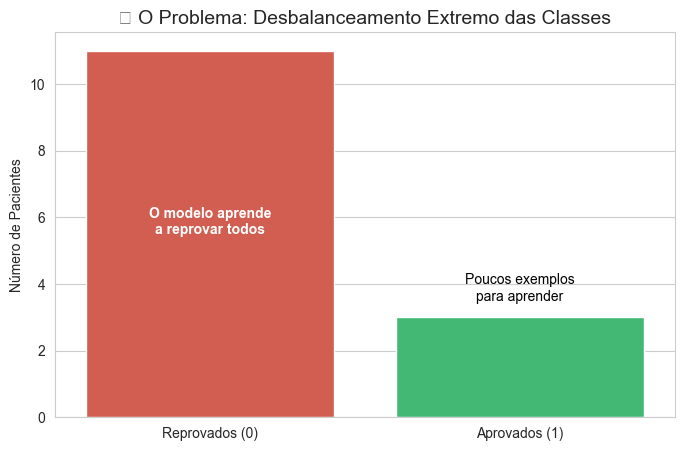

In [3]:
# 1. Carregar Dados Originais
df = pd.read_csv(caminho_dados)

# 2. Simular a criação do Target (igual fizemos no treino)
def gerar_target_simulado(row):
    # Regra simplificada para visualização
    if row['Necessidade_Dialise'] == 1 or row['Sinais_Vitais_O2_Suporte'] == 1:
        return 0 # Reprovado
    if row['Sinais_Gastro_Hepato'] == 1:
        return 1 # Aprovado
    return 0

df['Target'] = df.apply(gerar_target_simulado, axis=1)

# 3. Visualizar o Desequilíbrio
contagem = df['Target'].value_counts()
labels = ['Reprovados (0)', 'Aprovados (1)']

plt.figure(figsize=(8, 5))
ax = sns.barplot(x=labels, y=contagem.values, palette=['#e74c3c', '#2ecc71'])
plt.title('🚨 O Problema: Desbalanceamento Extremo das Classes', fontsize=14)
plt.ylabel('Número de Pacientes')

# Anotação explicando o problema
plt.text(0, contagem[0]/2, "O modelo aprende\na reprovar todos", ha='center', color='white', fontweight='bold')
plt.text(1, contagem[1] + 0.5, "Poucos exemplos\npara aprender", ha='center', color='black')

plt.show()

# 3. A Solução Técnica: Balanceamento via Oversampling ⚖️

Para corrigir o viés identificado acima, aplicamos uma técnica de Engenharia de Dados chamada **Oversampling**.

**O que estamos fazendo:**
1.  Isolamos os poucos casos positivos (Aprovados).
2.  Duplicamos esses casos matematicamente até que a quantidade se equipare aos casos negativos.

**Resultado:** O modelo agora vê uma distribuição 50/50 e é "forçado" a aprender as características clínicas do paciente aprovado, em vez de ignorá-lo.

C:\Users\gfasg\AppData\Local\Temp\ipykernel_32592\714781397.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=labels, y=contagem_bal.values, palette=['#e74c3c', '#2ecc71'])
C:\Users\gfasg\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


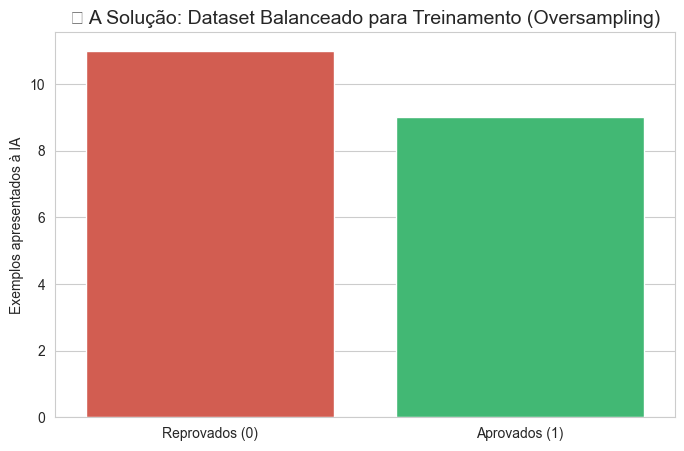

De 14 registros originais, passamos para 20 exemplos de treino.


In [5]:
# Simulação visual do Balanceamento
df_pos = df[df['Target'] == 1]
df_neg = df[df['Target'] == 0]

# Multiplicamos os positivos (exatamente como no seu código train_xgboost.py)
fator = len(df_neg) // len(df_pos)
df_balanceado = pd.concat([df_neg] + [df_pos] * fator)

# Plotar o "Depois"
contagem_bal = df_balanceado['Target'].value_counts()

plt.figure(figsize=(8, 5))
sns.barplot(x=labels, y=contagem_bal.values, palette=['#e74c3c', '#2ecc71'])
plt.title('✅ A Solução: Dataset Balanceado para Treinamento (Oversampling)', fontsize=14)
plt.ylabel('Exemplos apresentados à IA')
plt.show()

print(f"De {len(df)} registros originais, passamos para {len(df_balanceado)} exemplos de treino.")

# 4. Explicabilidade da IA (XGBoost Feature Importance) 🧠

Não basta a IA funcionar, precisamos entender **por que** ela toma decisões. Aqui extraímos as variáveis que o modelo considerou mais importantes.

**O que observar:**
* **Termos TF-IDF:** Se palavras como `tfidf_ascite` ou `tfidf_baixo` aparecerem, mostra que o modelo está lendo e interpretando o texto clínico.
* **Flags Clínicas:** Se `Necessidade_Dialise` ou `Sinais_Gastro` aparecerem, mostra que o modelo respeita as flags estruturadas.

C:\Users\gfasg\AppData\Local\Temp\ipykernel_32592\813539565.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Peso (Importância)', y='Variável', data=df_imp, palette='magma')
C:\Users\gfasg\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 129504 (\N{BRAIN}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


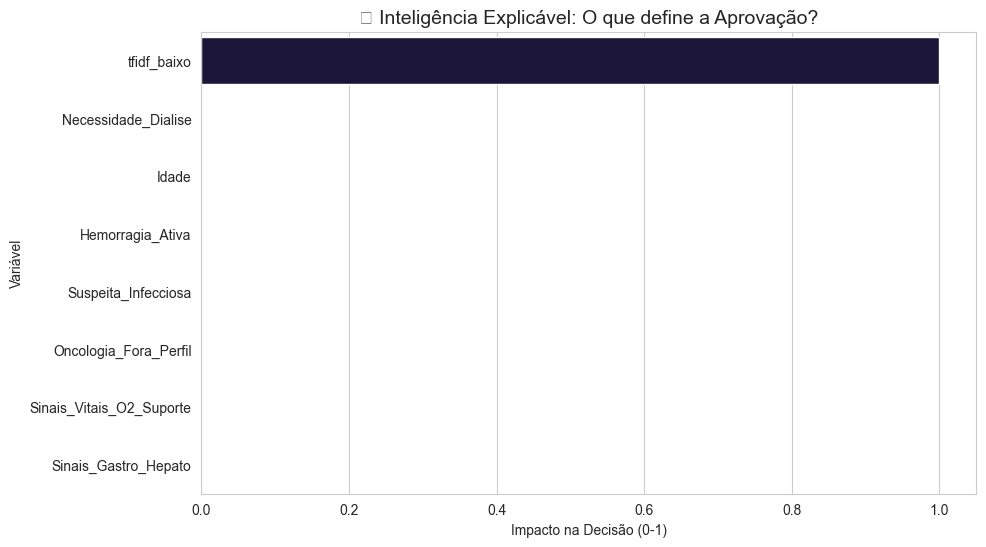

Nota: Se 'tfidf_...' aparecer, significa que o modelo aprendeu termos médicos específicos do texto.


In [6]:
# Carregar o modelo treinado
if os.path.exists(caminho_modelo):
    model = XGBClassifier()
    model.load_model(caminho_modelo)
    
    # Extrair features
    features = model.get_booster().feature_names
    importancias = model.feature_importances_
    
    # Criar DataFrame
    df_imp = pd.DataFrame({'Variável': features, 'Peso (Importância)': importancias})
    df_imp = df_imp.sort_values(by='Peso (Importância)', ascending=False).head(8)
    
    # Plotar
    plt.figure(figsize=(10, 6))
    sns.barplot(x='Peso (Importância)', y='Variável', data=df_imp, palette='magma')
    plt.title('🧠 Inteligência Explicável: O que define a Aprovação?', fontsize=14)
    plt.xlabel('Impacto na Decisão (0-1)')
    plt.show()
    
    print("Nota: Se 'tfidf_...' aparecer, significa que o modelo aprendeu termos médicos específicos do texto.")
else:
    print("❌ Modelo não encontrado. Rode o treino antes.")

# 5. Simulador de Regulação (Demo Interativa) 🎮

Esta é a interface final do sistema **ARIS**.

**Arquitetura Híbrida de Segurança:**
Implementamos uma **Safety Layer** (Camada de Segurança) no código de inferência.
1.  **Protocolo Soberano:** Se o paciente tiver critérios de exclusão (ex: Diálise, O2), o sistema reprova **imediatamente** (Regra Rígida).
2.  **Inteligência Artificial:** A IA só é consultada se o paciente passar pela triagem de segurança.

**Teste você mesmo:**
* *Cenário de Bloqueio:* Marque "Usa O2" e veja o bloqueio imediato.
* *Cenário de IA:* Desmarque os riscos e digite "Paciente com ascite e baixo risco".

In [7]:
# Importar nossa classe de inferência
from src.models.inference import ArisPredictor
import ipywidgets as widgets
from IPython.display import display, clear_output

# --- INICIALIZAÇÃO ---
# Removido o try/except para vermos o erro real se acontecer
predictor = ArisPredictor()

# --- Interface Visual ---
style = {'description_width': 'initial'}

# Inputs
txt_idade = widgets.IntSlider(value=50, min=18, max=100, description='Idade:', style=style)
drop_sexo = widgets.Dropdown(options=['MASCULINO', 'FEMININO'], description='Sexo:', style=style)
chk_dialise = widgets.Checkbox(value=False, description='Faz Diálise?')
chk_o2 = widgets.Checkbox(value=False, description='Usa O2?')
chk_instavel = widgets.Checkbox(value=False, description='Instabilidade Hemodinâmica?')

txt_clinico = widgets.Textarea(
    value='Paciente com ascite volumosa e cirrose. Nega dispneia.',
    placeholder='Descreva o caso...',
    description='Quadro Clínico:',
    layout=widgets.Layout(width='90%', height='80px'),
    style=style
)

btn_predict = widgets.Button(
    description='⚡ Analisar Elegibilidade',
    button_style='primary',
    layout=widgets.Layout(width='50%')
)
out = widgets.Output()

def realizar_predicao(b):
    with out:
        clear_output()
        # Montar dicionário do paciente
        paciente = {
            'Idade': txt_idade.value,
            'Sexo': drop_sexo.value,
            'Necessidade_Dialise': 1 if chk_dialise.value else 0,
            'Sinais_Vitais_O2_Suporte': 1 if chk_o2.value else 0,
            'Instabilidade_Hemodinamica': 1 if chk_instavel.value else 0,
            'Diagnostico_Texto_Livre': txt_clinico.value,
        }
        
        # Predição
        res = predictor.predict_new_case(paciente)
        
        # Resultado Visual
        cor = '#27ae60' if res['aprovado'] else '#c0392b'
        icone = '✅' if res['aprovado'] else '⛔'
        
        display(widgets.HTML(f"""
            <div style='background-color: {cor}; color: white; padding: 15px; border-radius: 8px; margin-top: 10px;'>
                <h2>{icone} {res['diagnostico_modelo']}</h2>
                <p style='font-size: 16px'>Probabilidade de Aprovação: <b>{res['probabilidade_percentual']}%</b></p>
            </div>
        """))

btn_predict.on_click(realizar_predicao)

# Layout
display(widgets.VBox([
    widgets.HTML("<h3>🏥 Simulador de Regulação (ARIS AI)</h3>"),
    widgets.HBox([txt_idade, drop_sexo]),
    widgets.HBox([chk_dialise, chk_o2, chk_instavel]),
    txt_clinico,
    btn_predict,
    out
]))

🤖 Inicializando o motor de inferência ARIS...
📂 Buscando artefatos em: c:\Users\gfasg\OneDrive\Área de Trabalho\ARIS\ARIS-Regulacao-Inteligente
✅ Modelo carregado com sucesso.


# 6. Raio-X do Vocabulário da IA 📖

Como treinamos com poucos dados ("Small Data"), o vocabulário da IA é limitado. Aqui listamos exatamente quais palavras o modelo conhece.

**Por que isso é importante?**
Isso explica o comportamento do modelo. Se digitarmos uma palavra que não está nesta lista, a IA a ignora. Para a demonstração funcionar bem, devemos usar termos que existam neste dicionário (ex: *ascite, cirrose, baixo, risco*).

In [8]:
# Caminho para achar os arquivos
sys.path.append(os.path.abspath('..'))
caminho_vetor = '../models/vectorizers/tfidf_vectorizer.pkl'

if os.path.exists(caminho_vetor):
    # Carregar o tradutor da IA
    vectorizer = joblib.load(caminho_vetor)
    vocabulario = vectorizer.get_feature_names_out()
    
    print(f"📖 A IA conhece apenas estas {len(vocabulario)} palavras/termos:")
    print("-" * 60)
    
    # Mostrar em formato de tabela para facilitar
    print(pd.DataFrame(vocabulario, columns=['Palavras Conhecidas']).to_string())
    
    print("-" * 60)
    print("💡 DICA PARA A DEMO: Use algumas dessas palavras no texto do simulador!")
else:
    print("❌ Vetorizador não encontrado.")

📖 A IA conhece apenas estas 50 palavras/termos:
------------------------------------------------------------
     Palavras Conhecidas
0                    abd
1              abdominal
2                    acv
3                acv rcr
4                afebril
5                    aht
6               alergias
7                     ar
8                  ar mv
9                  baixo
10          baixo ventre
11                   bnf
12                bnf ss
13            consciente
14  consciente orientada
15           depressível
16                  dias
17                   dor
18         dor abdominal
19                 exame
20                    fc
21                 febre
22                   fez
23                função
24          função renal
25                   has
26              história
27                    kg
28                    mv
29                mv aht
30           necessidade
31                  nega
32                 nesse
33             orientada
34            pa